# Introduction to Model Building with TensorFlow

Regression is a supervised learning technique. It is used to predict continuous numeric values, such as house prices, stock prices, or any other numeric value.

In this article, it is my sole purpose to show you the how easily we can actually make a neural model and discuss underlying mathematical concepts.

I make this type of article regularly. If you want to read my other articles on ML and web dev follow me on:

- [LinkedIn](https://www.linkedin.com/in/pro-programmer/),
- [YouTube](http://www.youtube.com/@itvaya),
- [github](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow),
- [Gmail](talukderrishat2@gmail.com),
- [discord](https://discord.gg/ZB495XggcF),

## Pre-requisites

- Python.
- Numpy.
- Pandas.
- Matplotlib/Seaborn.
- Basics of data analysis and preprocessing.
- Basics ML terminologies.


# Installations

So, as we are making a `neural network using TensorFlow`, we will need to install it. To do so, we will use the following command:

```bash
    pip install tensorflow
```

or If you have conda installed,
    
```bash
    conda install tensorflow
```

Now, let's import the necessary libraries and check the version of TensorFlow we are using.


In [1]:
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

tf.__version__

2026-08-05 17:14:06.891943: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


'2.20.0'

There you go... We are ready to start working and here we have the `TensorFlow` `2.20.0` installed.

SOOO, we have imported the libraries and now what do we do?

# Data Generation

To make a model in TensorFlow, we need data. So, let's create some data to work with. 

We will create a simple dataset with numpy and then we will use TensorFlow to create a model that can predict the output based on the input.

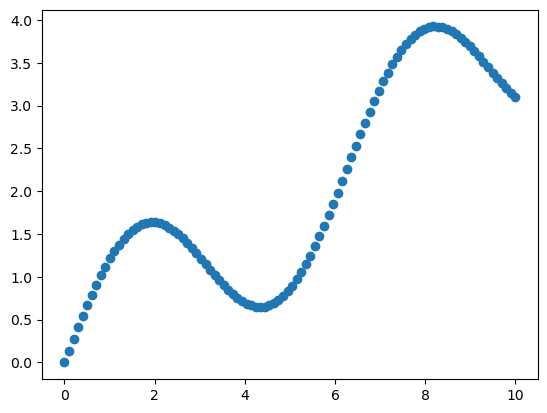

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sine_wave(x, angle=0):
    theta = np.radians(angle)
    return np.tan(theta)*x + np.sin(x)

X = np.linspace(0, 10, 100)
y = sine_wave(X, angle=20)
plt.scatter(X, y)

Don't get scared of the code above. Let's me explain.

I wanted to make a dataset with somewhat of a complex pattern. So, I'm using a `tilted sine wave` with angle 20 degrees.

For this I made the function `sine_wave`. This function represents the equation $y = \tan(\theta)x + \sin(x)$ where $\theta$ is the angle of the tangent line.

For, x values I'm taking 100 evenly spaced values between 0 and 10 using the `np.linspace()` function.

And now we pass the whole `x` to the `sine_wave` function and then we plot the `x` and `y` values.

And we see the dataset is generating almost a perfect squiggle. That goes up and down as the value of x rises.

My goal of this article is to show you if we can make a model that can predict this pattern.

One last thing I want to do to the dataset is add some randomness. 

The data looks too clean. Real life data is messy. These are generally referred to as **noisy data**.

So, I'll just add some noise to the $y$ values.

> Here, x is our feature and y is our target to predict.

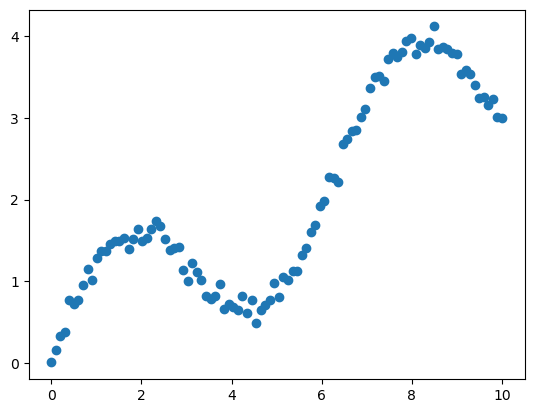

In [3]:
y = y + np.random.normal(loc=0, scale=0.1, size=X.shape)

plt.scatter(X, y)


Nice, now it looks like a real dataset.

We have `X` which is our feature and we have `y` which is our target.

So, now only one things left to do. We need to create a model.

# Steps in modelling a neural network

A neural network model mainly has three parts.

1. **Input Layer**: This is the layer that takes in the input.
2. **Hidden Layers**: This is the layer that contains the hidden layers.
3. **Output Layer**: This is the layer that contains the output.

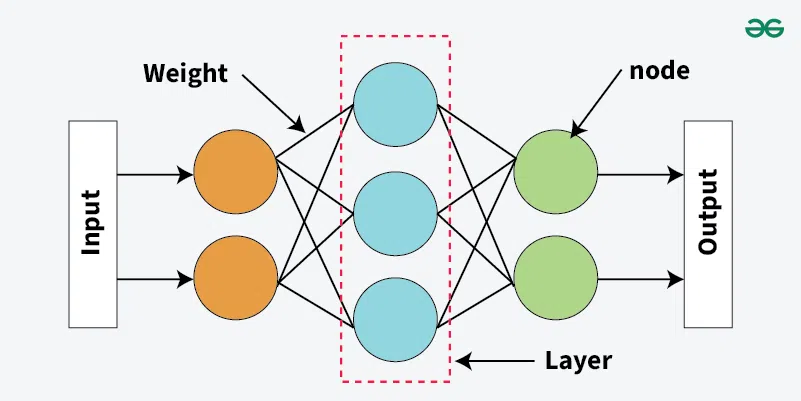

> To get e greater understanding of neural networks I heavily recommend watching [this](https://www.youtube.com/watch?v=CqOfi41LfDw)

First, let's make an input layer.

The input layer defines the input shape of each row in the data. As we only have one feature, the input shape will be 1.

Now, how do you find the shape of any row?

Simple, just take any index from the data and check the shape of that index using the `shape` function.

In [4]:
X.shape

(100,)

In [5]:
X[0].shape

()

If it's a empty bracket, then it's a scalar meaning there's only one value in that index.

> Scalar is 0-dimensional.

Which can be a issue because the input layer will expect at least one dimension.

So, I'll tranform the scalar to a 1-dimensional array using the `np.expand_dims()` function.

In [6]:
X_reshaped = np.expand_dims(X, axis=1)
X_reshaped.shape

(100, 1)

In [7]:
X_reshaped[0].shape

(1,)

Now, we can see the shape is (1,) which means it is a 1-dimensional array with one element.

Let's see if eveything is still the same of not.

In [8]:
X[:5], X_reshaped[:5]

(array([0.       , 0.1010101, 0.2020202, 0.3030303, 0.4040404]),
 array([[0.       ],
        [0.1010101],
        [0.2020202],
        [0.3030303],
        [0.4040404]]))

Yes! the values looks the same just now each value has it's one array.

Now, let's define a model.

In [9]:
from keras.models import Sequential

model = Sequential()


Here, I'm defining a fully connected feed forward network using the `Sequential` class from the `keras` module.

> Keras is a high level API for TensorFlow you can also use the `tf.keras` module which is exactly the same as the `keras` module. I used keras because vs code has intellisense support for keras.

Now, we can start adding layers to the model.

In [10]:
from keras.layers import Input

model.add(Input(shape=(1,)))

We can use `model.add()` to add layers to the model.

Now, to add the input layer we have to use `Input` function. This function will expect use to pass in the input shape as an argument.

So, as each row of the data has one feature, the input shape will be `(1,)`. So, just specify `(1,)` as the input shape.

Now, we make the hidden layers.

As we have a fairly complex pattern, we might need multiple hidden layers, But first we should think about how many neurons should in the first hidden layer.

It's a common practice to use 2-4 times the number of features or multiple of 16 as the number of neurons in the first hidden layer.

We can choose any number of neurons if we want. Let's take 64.

In [11]:
from keras.layers import Dense

model.add(
    Dense(
        units=64,
        activation='relu'
    )
)

I0000 00:00:1785928449.289302  992992 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9514 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


There you go.

Let's break it down. To add a fully connected hidden layer we use the `Dense` class from the `keras` module.

This class will do most of heavy lifting for use. We just have to specify the number of neurons and the `activation function`.

What is a activation function?

An activation function is a function that is applied to the output of a layer. It is used to introduce `non-linearity` into the model.

> Learn more about activation functions [here](https://en.wikipedia.org/wiki/Activation_function)

There can be a lot of activation functions but the simplest and most common one is the `ReLU` activation function.

> Relu activation function is defined as `max(0, x)`. If the `weighted sum z` is less than 0, then the output is 0. If it is greater than 0, then the output is the same as the input.

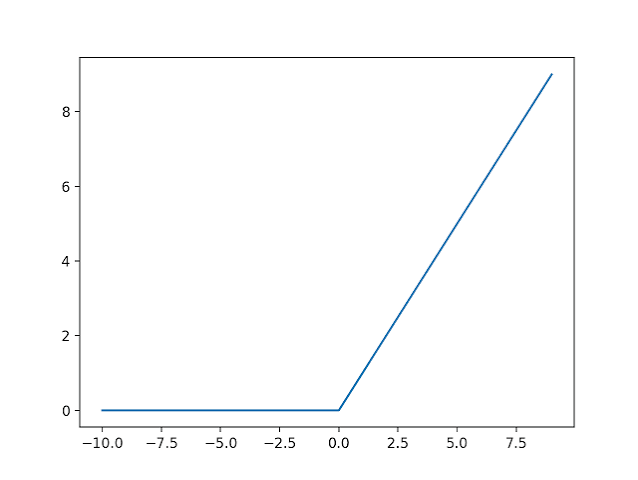


You can just write the name of the activation function as an argument in the `Dense` class.

Let's Add another one.


In [12]:
from keras.activations import relu

model.add(
    Dense(
        units=64,
        activation=relu
    )
)

A little side-quest for you guys. Try to figure out how you can pass other activation functions as an argument in the `Dense` class.

You can also pass `relu` as the activation function as an argument in dense class for better control and customization.

I'll keep it like this for now. Let's add the output layer.

As we are predicting a single continuous value we can directly use the `Dense` class with a single neuron. this neurons output will the final output of the model.

And we cannot put a activation in the output layer because if we do the final outcome will change which will be a problem.

In [13]:
model.add(
    Dense(units=1)
)

And trust me we are done. We've actually made a neural network model just like that.

Let's see how out model looks like.

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

Looking goooood.

This model has 4,353 Trainable parameters and ready to learn. So, time to tell it how to learn.

# Compiling the model

This is where we tell the model how to learn.

First we define the optimizer.

What is a optimizer?

An optimizer is a function that is used to update the `parameters` of the model. We have 4,353 parameters and the optimizer will update these 4,353 parameters over and over again to find a optimal solution.

Most common optimizers are the `Adam` optimizer and the `SGD` optimizer. You can learn about both [here](https://en.wikipedia.org/wiki/Stochastic_gradient_descent).

Another thing we need a is `loss function`. A loss function is a function that is used to calculate the error in the model. Which will be used by the optimizer to update the parameters.

It's kind of a loop. The model predicts something loss function will calculate the error then the optimizer will update the parameters and then again the loss function will calculate the error and so on.

For loss function we have a lot of choices like `mean absolute error`, `mean squared error`, `cross entropy`, etc. Most common and basic is the `mean squared error` loss function.

> Read more about loss functions [here](https://en.wikipedia.org/wiki/Loss_function)

In [15]:
from keras import losses, metrics, optimizers

model.compile(
    optimizer=optimizers.Adam(),
    loss=losses.mean_squared_error,
    metrics=[metrics.mean_absolute_error]
)

And the model is ready to train.

In the `model.compile` we have to pass the optimizer, loss function and metrics.

Matrics should be a list of evaluation functions used to monitor the training and testing process. There can be multiple metrics but for now we will use `mean absolute error` as a metric.

Now, we can just start training.

In [16]:
model.fit(X_reshaped, y, epochs=100, verbose=2)

Epoch 1/100


2026-08-05 17:14:10.323256: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c69bc0047c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-05 17:14:10.323267: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-05 17:14:10.337599: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-05 17:14:10.422473: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
I0000 00:00:1785928450.986852  993053 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 - 2s - 406ms/step - loss: 8.0421 - mean_absolute_error: 2.4518
Epoch 2/100
4/4 - 0s - 7ms/step - loss: 4.6160 - mean_absolute_error: 1.8135
Epoch 3/100
4/4 - 0s - 7ms/step - loss: 2.2854 - mean_absolute_error: 1.2397
Epoch 4/100
4/4 - 0s - 7ms/step - loss: 1.0184 - mean_absolute_error: 0.8420
Epoch 5/100
4/4 - 0s - 7ms/step - loss: 0.5246 - mean_absolute_error: 0.6324
Epoch 6/100
4/4 - 0s - 7ms/step - loss: 0.5277 - mean_absolute_error: 0.6129
Epoch 7/100
4/4 - 0s - 7ms/step - loss: 0.6917 - mean_absolute_error: 0.6710
Epoch 8/100
4/4 - 0s - 7ms/step - loss: 0.7607 - mean_absolute_error: 0.6946
Epoch 9/100
4/4 - 0s - 7ms/step - loss: 0.6889 - mean_absolute_error: 0.6683
Epoch 10/100
4/4 - 0s - 7ms/step - loss: 0.5663 - mean_absolute_error: 0.6229
Epoch 11/100
4/4 - 0s - 7ms/step - loss: 0.4820 - mean_absolute_error: 0.5982
Epoch 12/100
4/4 - 0s - 7ms/step - loss: 0.4649 - mean_absolute_error: 0.6050
Epoch 13/100
4/4 - 0s - 7ms/step - loss: 0.4684 - mean_absolute_error: 0.6088
Epoch

And that's how we do it.

We use the `model.fit()` method to train the model.

In ths method we have to pass the input data, output data, number of epochs and verbose.

Input data is `X_reshaped` and output data is `y`. 

Epochs is the number of times we want to train the model. Here I'm using 100 epochs.

Verbose defines how much information we want to print.

Now, If you look at the output data. We have a fairly reasonable model.

But we cannot be sure if the model learned the right pattern or not.

# Prediction

We can very easily predict the output of the model by just calling the `model.predict()` method and passing testing data.

As we dont have testing data we will just use the training data and see how the predicted pattern looks like.

In [17]:
predictions = model.predict(X_reshaped)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


now, we can just plot the predicted values and the actual values.

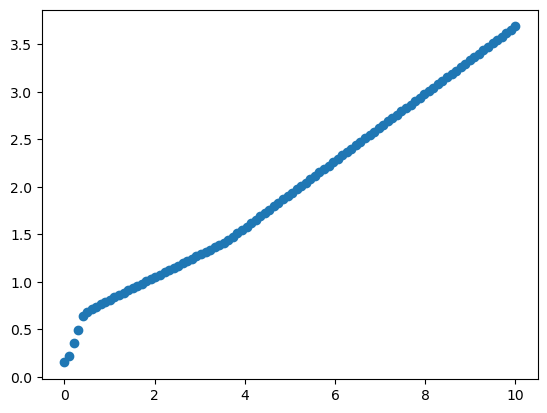

In [18]:
plt.scatter(X, predictions)

Well, That's not good but atleast it got the angle somewhat right.

As you can see the model couldn't capture the pattern completely. We should train for more epochs.

We don't have to remake the whole model again. We can just call the `model.fit()` method again and it'll continue training from where it left off.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


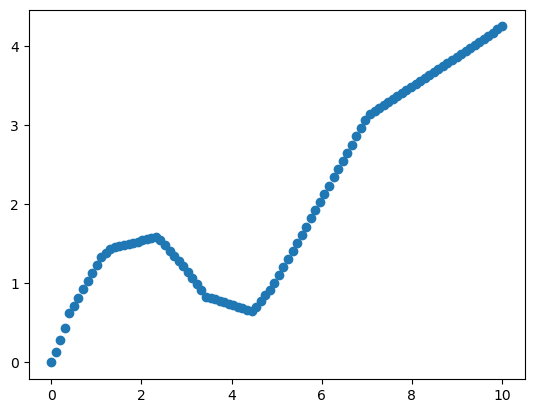

In [19]:
model.fit(X_reshaped, y, epochs=1000, verbose=0)
predictions = model.predict(X_reshaped)

plt.scatter(X, predictions)

Well, now it looks better. After 1100 iterations the model can predict somewhat of the pattern.

Noice.

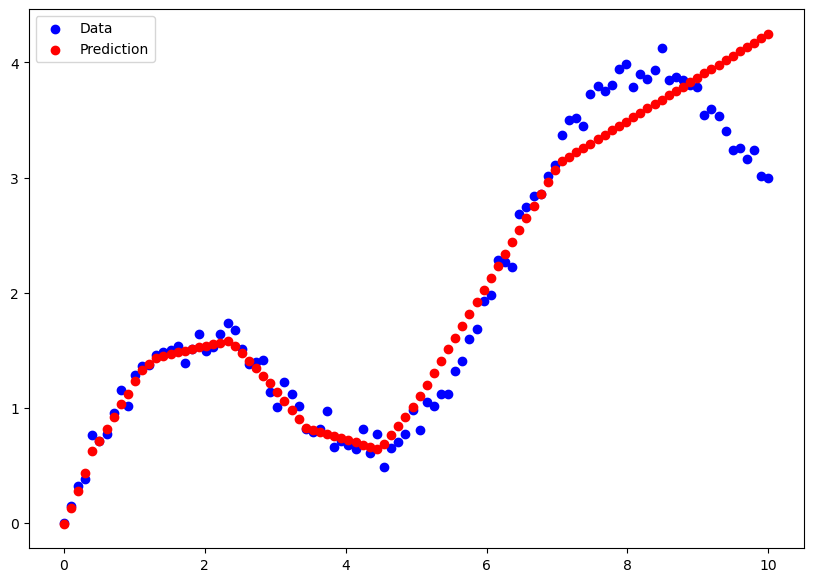

In [20]:
plt.figure(figsize=(10, 7))
plt.scatter(X, y, c='b', label='Data')
plt.scatter(X, predictions, c='r', label='Prediction')
plt.legend()

Not bad right?!

# Saving a model


There are two main format:
- Save model format
- HDF5 format

In [21]:
model.save('simple_model.keras')

To load the model we can just

In [22]:
#loading the model
loaded_model = tf.keras.models.load_model('simple_model.keras')

Tensorflow is pretty smart. It will automatically reshape the input data if it is a vector. Tensorflow will automatically transform the input data to a 2-dimensional array. So, we can predict the output of the model by just passing the whole X without re-shaping. 

But for now let's not get into that stuff.

> I'll talk more about the input shape on a later article.

In [23]:
loaded_predict = loaded_model.predict(X_reshaped)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


And voila! we have a loaded model. It works perfectly.

# Conclusion

Hope this helps. I skipped talking about a lot of concepts in this article. Just  do some research and I think you'll understand everything.

Happy Deep Learning!